<a href="https://colab.research.google.com/github/duddet01/Learning_ai/blob/main/Makemore_w_context.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [5]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-03-20 23:11:59--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.1’

names.txt.1         100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-03-20 23:11:59 (14.4 MB/s) - ‘names.txt.1’ saved [228145/228145]



In [6]:
#read all words
words=open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [7]:
len(words)

32033

In [8]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars) }
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [9]:

#Complete dataset

block_size=3 #context length: how many ch to predict the next one
X,Y=[],[]

for w in words:
  # print(w)
  context=[0]*block_size
  for ch in w + '.':
    ix= stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context),'---->',itos[ix])
    context=context[1:]+[ix] #crop and append
X=torch.tensor(X)
Y=torch.tensor(Y)


In [10]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [11]:
C=torch.randn((27,2))

In [12]:
X.shape

torch.Size([228146, 3])

In [13]:
emb=C[X]
emb.shape

torch.Size([228146, 3, 2])

In [14]:
W1=torch.randn((6,100))
b1=torch.randn(100)

In [15]:
torch.cat([emb[:,0,:] ,emb[:,1,:], emb[:,2,:]],1).shape

torch.Size([228146, 6])

In [16]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([228146, 6])

In [17]:
a=torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [18]:
a.shape

torch.Size([18])

In [19]:
a.view(3,3,2).shape

torch.Size([3, 3, 2])

In [22]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [23]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [24]:
for p in parameters:
  p.requires_grad=True

In [25]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre


In [26]:
lri=[]
lossi=[]
stepi=[]

In [29]:
from tqdm import tqdm
for i in tqdm(range(100000)):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

100%|██████████| 100000/100000 [01:15<00:00, 1322.73it/s]


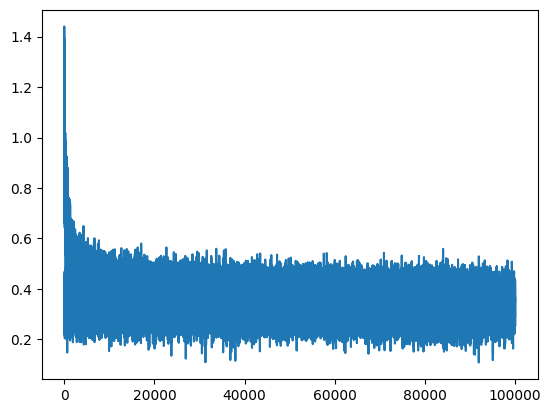

In [30]:
plt.plot(stepi,lossi)

In [31]:
#Evaluation of loss for the dev dataset:

emb=C[Xdev]
h=torch.tanh(emb.view(-1,30) @ W1 + b1)
logits=h @ W2 +b2
loss=F.cross_entropy(logits,Ydev)
loss

tensor(2.2836, grad_fn=<NllLossBackward0>)

In [32]:
emb=C[Xtr]
h=torch.tanh(emb.view(-1,30) @ W1 + b1)
logits=h @ W2 +b2
loss=F.cross_entropy(logits,Ytr)
loss

tensor(2.2296, grad_fn=<NllLossBackward0>)

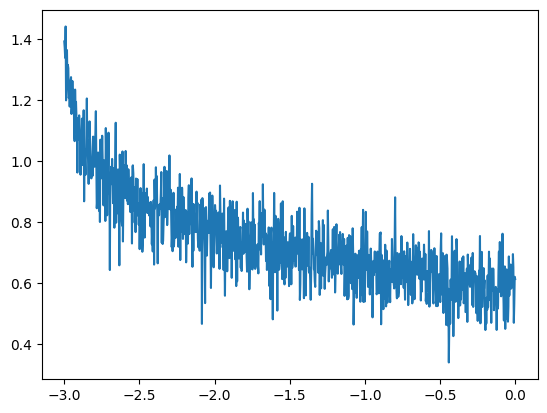

In [40]:
plt.plot(lre,torch.tensor(lossi[:len(lre)]).detach().numpy())

In [37]:
#Training split, dev/validation split, test split
#80% , 10% , 10%

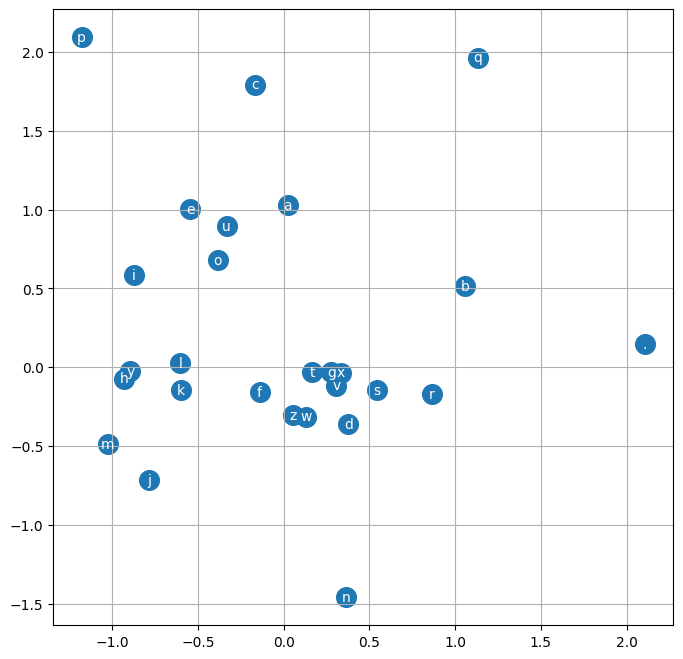

In [35]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [36]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carlah.
aal.
havian.
mylorey.
jahkandon.
jazhnevangelynn.
jaqui.
jermana.
chaigh.
jaleigh.
ham.
joannedinnishonnah.
jadiquince.
madiarinix.
kael.
ivraj.
edde.
iia.
giannaysalyna.
asmond.
